# Bank Customer Churn & Retention Analytics
**Author:** Jithma Kamburugamuwa  
**Objective:** Identify key customer churn drivers across demographics, account balances, and product engagements to formulate proactive retention strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('data/raw/Bank Customer Churn Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 1. Data Integrity & Summary Statistics
Verifying missing values and reviewing key distributions across the 10,000 banking records.

In [2]:
print("Missing values per column:\n", df.isnull().sum())
df.describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]

Missing values per column:
 customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64


,count,mean,std,min,50%,max
customer_id,10000.0,1.569094e+07,71936.186123,15565701.00,1.569074e+07,15815690.00
credit_score,10000.0,6.505288e+02,96.653299,350.00,6.520000e+02,850.00
age,10000.0,3.892180e+01,10.487806,18.00,3.700000e+01,92.00
tenure,10000.0,5.012800e+00,2.892174,0.00,5.000000e+00,10.00
balance,10000.0,7.648589e+04,62397.405202,0.00,9.719854e+04,250898.09
products_number,10000.0,1.530200e+00,0.581654,1.00,1.000000e+00,4.00
credit_card,10000.0,7.055000e-01,0.455840,0.00,1.000000e+00,1.00
active_member,10000.0,5.151000e-01,0.499797,0.00,1.000000e+00,1.00
estimated_salary,10000.0,1.000902e+05,57510.492818,11.58,1.001939e+05,199992.48
churn,10000.0,2.037000e-01,0.402769,0.00,0.000000e+00,1.00


## 2. Demographic & Segment Churn Analysis
Visualizing overall portfolio churn distribution, geographic variance (France, Spain, Germany), and age risk profiles.

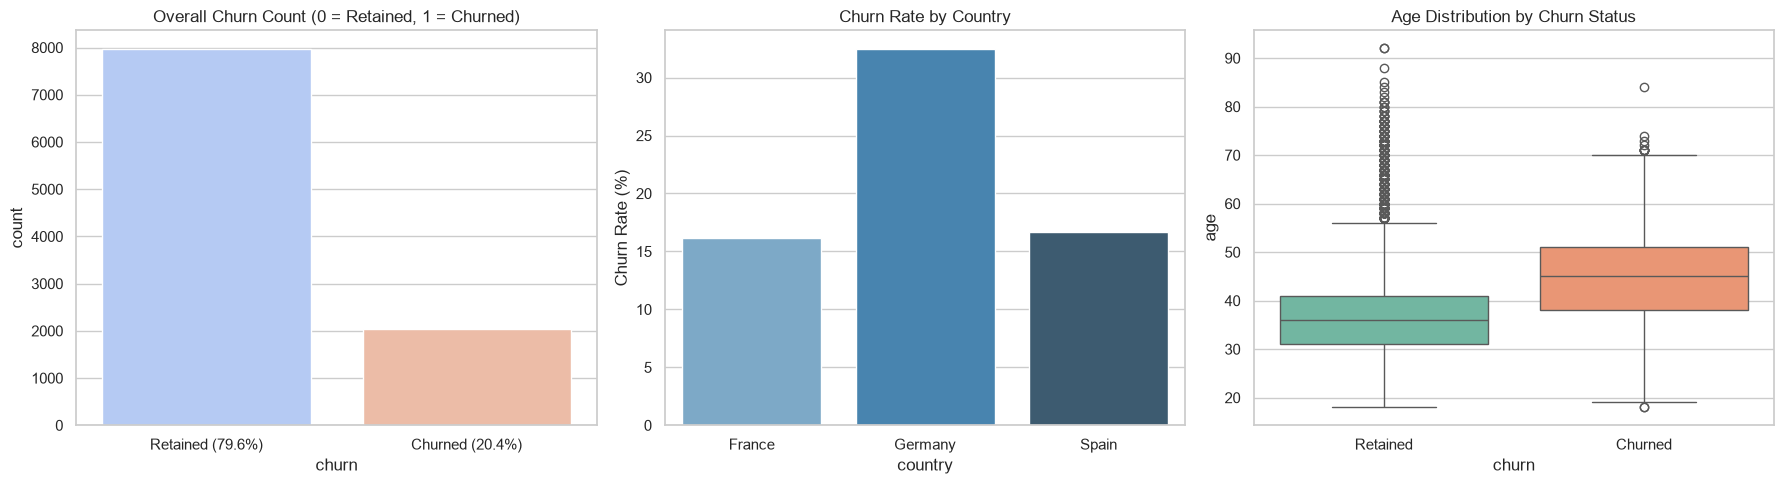

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall Churn Distribution
sns.countplot(ax=axes[0], data=df, x='churn', hue='churn', palette='coolwarm', legend=False)
axes[0].set_title('Overall Churn Count (0 = Retained, 1 = Churned)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained (79.6%)', 'Churned (20.4%)'])

# 2. Churn Rate by Country
churn_by_country = (df.groupby('country')['churn'].mean() * 100).reset_index()
sns.barplot(ax=axes[1], data=churn_by_country, x='country', y='churn', hue='country', palette='Blues_d', legend=False)
axes[1].set_title('Churn Rate by Country')
axes[1].set_ylabel('Churn Rate (%)')

# 3. Age Distribution by Churn Status
sns.boxplot(ax=axes[2], data=df, x='churn', y='age', hue='churn', palette='Set2', legend=False)
axes[2].set_title('Age Distribution by Churn Status')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.show()

## 3. Feature Correlation Analysis
Evaluating linear correlations between customer attributes and exit behavior.

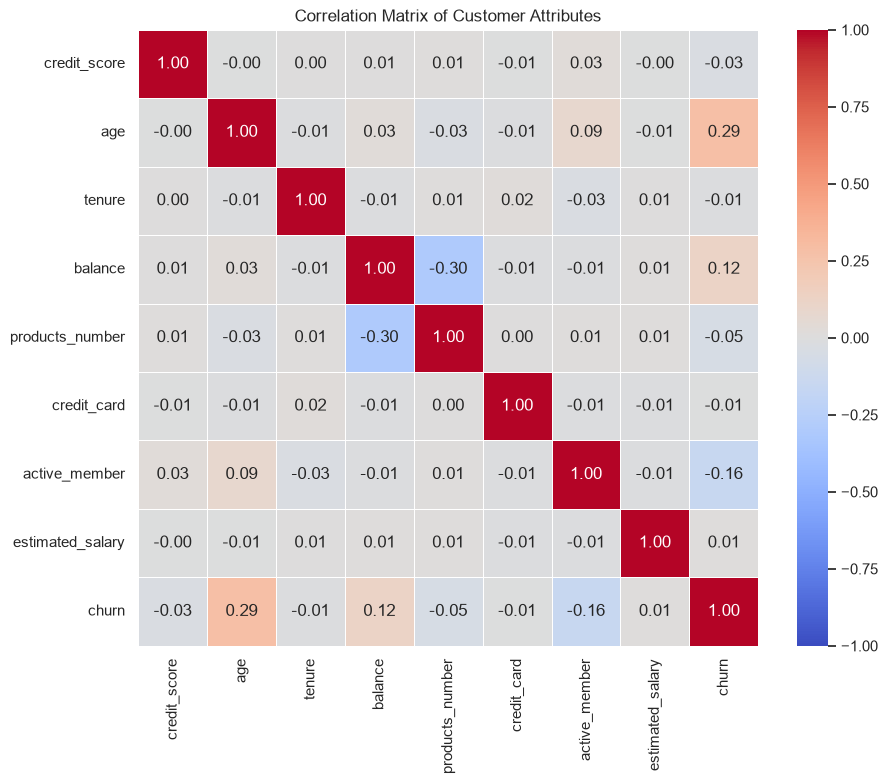

In [4]:
numeric_df = df.select_dtypes(include=['int64', 'float64']).drop(columns=['customer_id'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Matrix of Customer Attributes')
plt.show()

## 4. Key Business Findings & Recommendations
* **Regional Disparity:** Germany presents a **32.44% churn rate** (n=2,509 — double France and Spain) alongside the highest average deposit balance ($119.7k). Targeted relationship management in Germany is critical.
* **Demographic Risk:** Customers aged **46–60** exhibit the highest attrition (**51.12%**, n=1,647), leading to over **$75M** in deposit runoff.
* **Product Saturation:** Customers holding 3+ products show attrition exceeding **80%** (n=266 at 3 products, n=60 at 4), suggesting friction with multi-product service fees or onboarding quality. These segments are only 3.3% of the portfolio, so treat this as a signal to investigate rather than a stable estimate.

### Caveats
* **36% of accounts (3,617) carry a zero balance**, which inflates balance-based comparisons — Germany's higher average balance is partly an artifact of Germany having very few zero-balance accounts.
* `churn` is a static label with no timestamp, so these are cross-sectional associations, not causal or time-series effects.